In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
import warnings
warnings.filterwarnings('ignore')

#Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)

In [3]:
DATA_PATH = r"C:/Users/admin/Desktop/SOFTWARE/E-commerce analytics project/Dataset/"

customers      = pd.read_csv(r"C:/Users/admin/Desktop/SOFTWARE/E-commerce analytics project/Dataset/" + "olist_customers_dataset.csv")
orders         = pd.read_csv("C:/Users/admin/Desktop/SOFTWARE/E-commerce analytics project/Dataset/" + "olist_orders_dataset.csv")
items          = pd.read_csv(r"C:/Users/admin/Desktop/SOFTWARE/E-commerce analytics project/Dataset/" + "olist_order_items_dataset.csv")
payments       = pd.read_csv(r"C:/Users/admin/Desktop/SOFTWARE/E-commerce analytics project/Dataset/" + "olist_order_payments_dataset.csv")
reviews        = pd.read_csv(r"C:/Users/admin/Desktop/SOFTWARE/E-commerce analytics project/Dataset/" + "olist_order_reviews_dataset.csv")
products       = pd.read_csv(r"C:/Users/admin/Desktop/SOFTWARE/E-commerce analytics project/Dataset/" + "olist_products_dataset.csv")
cat_translation = pd.read_csv(r"C:/Users/admin/Desktop/SOFTWARE/E-commerce analytics project/Dataset/" + "product_category_name_translation.csv")
#Convert dates
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Data loaded successfully!")
print(f"Orders: {len(orders):,} | Customers: {len(customers):,} | Items: {len(items):,}")

Data loaded successfully!
Orders: 99,441 | Customers: 99,441 | Items: 112,650


In [4]:
#Merge
master = orders.merge(customers, on='customer_id', how='left')

#Order-level aggregates
item_agg = items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count'
}).rename(columns={'price': 'total_price', 'freight_value': 'total_freight', 
                   'order_item_id': 'num_items'})

master = master.merge(item_agg, on='order_id', how='left')
master['total_order_value'] = master['total_price'].fillna(0) + master['total_freight'].fillna(0)

#Payments
pay_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'mean',
    'payment_type': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'credit_card'
}).rename(columns={'payment_value': 'payment_total', 'payment_installments': 'avg_installments',
                   'payment_type': 'primary_payment_type'})
master = master.merge(pay_agg, on='order_id', how='left')

#Reviews
review_agg = reviews.groupby('order_id').agg({
    'review_score': 'mean',
    'review_id': 'count'
}).rename(columns={'review_score': 'avg_review_score', 'review_id': 'num_reviews'})
master = master.merge(review_agg, on='order_id', how='left')

#Product categories
items_cat = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(cat_translation, on='product_category_name', how='left')
cat_agg = items_cat.groupby('order_id')['product_category_name_english'].apply(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'unknown').reset_index()
cat_agg.columns = ['order_id', 'primary_category']
master = master.merge(cat_agg, on='order_id', how='left')

#Delivery metrics
master['delivery_days'] = (master['order_delivered_customer_date'] - 
                           master['order_purchase_timestamp']).dt.days
master['is_late'] = master['order_delivered_customer_date'] > master['order_estimated_delivery_date']
master['is_late'] = master['is_late'].fillna(False)

#Time features
master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M')
master['order_year'] = master['order_purchase_timestamp'].dt.year
master['order_dow'] = master['order_purchase_timestamp'].dt.dayofweek
master['order_hour'] = master['order_purchase_timestamp'].dt.hour

print(f"Master table: {master.shape}")

# completed orders for most analyses
delivered = master[master['order_status'] == 'delivered'].copy()
print(f"Delivered orders: {len(delivered):,}")

Master table: (99441, 28)
Delivered orders: 96,478



=== KEY BUSINESS KPIs ===
Total revenue (price + freight): R$15,419,774
Unique customers: 93,358
Avg order value: R$159.83
Avg review score: 4.16
Late delivery rate: 8.1%
Avg delivery days: 12.1


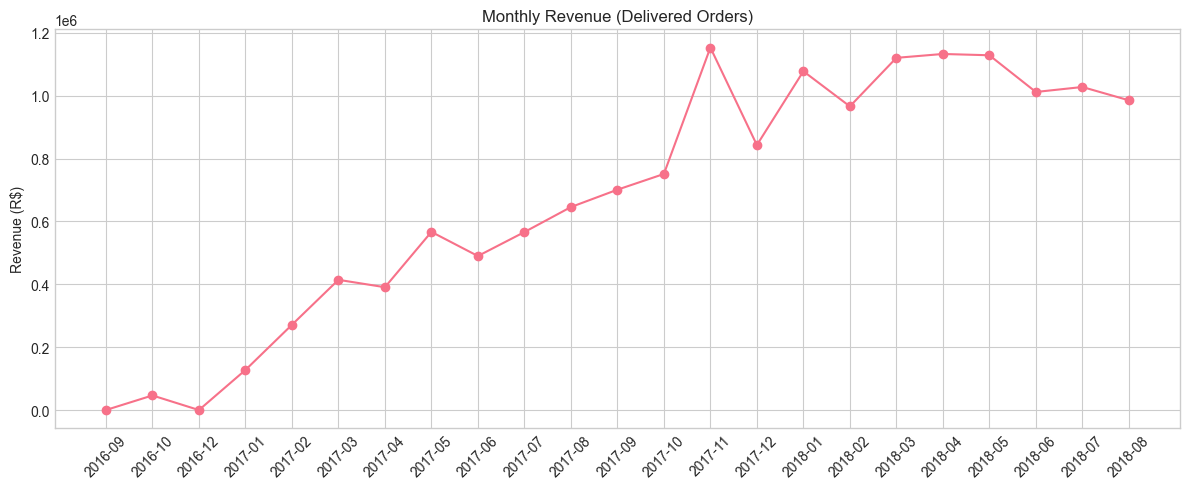


Avg review by late status:
is_late
False    4.294311
True     2.566506
Name: avg_review_score, dtype: float64

Top 15 categories by revenue:
                          revenue  orders
primary_category                         
health_beauty          1414013.93    8621
watches_gifts          1257834.94    5455
bed_bath_table         1240766.88    9240
sports_leisure         1115592.11    7478
computers_accessories  1037031.28    6520
furniture_decor         884501.51    6208
housewares              755045.39    5671
cool_stuff              688656.45    3516
auto                    671703.24    3804
garden_tools            566399.50    3411
toys                    542461.41    3759
baby                    473861.03    2794
perfumery               442990.28    3070
telephony               378088.49    4071
office_furniture        333889.26    1244


In [5]:
# Basic EDA & KPIs
print("\n=== KEY BUSINESS KPIs ===")
print(f"Total revenue (price + freight): R${delivered['total_order_value'].sum():,.0f}")
print(f"Unique customers: {delivered['customer_unique_id'].nunique():,}")
print(f"Avg order value: R${delivered['total_order_value'].mean():.2f}")
print(f"Avg review score: {delivered['avg_review_score'].mean():.2f}")
print(f"Late delivery rate: {delivered['is_late'].mean()*100:.1f}%")
print(f"Avg delivery days: {delivered['delivery_days'].mean():.1f}")

# Monthly revenue trend
from pathlib import Path

FIGURE_PATH = Path("outputs/figures")
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

monthly = delivered.groupby(delivered['order_purchase_timestamp'].dt.to_period('M')).agg(
    revenue=('total_order_value', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_unique_id', 'nunique')
).reset_index()
monthly['order_purchase_timestamp'] = monthly['order_purchase_timestamp'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly['order_purchase_timestamp'], monthly['revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue (Delivered Orders)')
plt.ylabel('Revenue (R$)')
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'monthly_revenue.png', dpi=150)
plt.show()
plt.close()

# Review score vs late delivery
print("\nAvg review by late status:")
print(delivered.groupby('is_late')['avg_review_score'].mean())

# Top categories
top_cats = (delivered.groupby('primary_category')
            .agg(revenue=('total_order_value', 'sum'), orders=('order_id', 'nunique'))
            .sort_values('revenue', ascending=False).head(15))
print("\nTop 15 categories by revenue:")
print(top_cats)

In [6]:
# RFM Analysis
from datetime import datetime, timedelta
from pathlib import Path

OUTPUT_PATH = Path("outputs")
FIGURE_PATH = OUTPUT_PATH / "figures"
TABLE_PATH  = OUTPUT_PATH / "tables"

FIGURE_PATH.mkdir(parents=True, exist_ok=True)
TABLE_PATH.mkdir(parents=True, exist_ok=True)

print("Folders ready:")
print(FIGURE_PATH.resolve())
print(TABLE_PATH.resolve())

snapshot_date = delivered['order_purchase_timestamp'].max() + timedelta(days=1)

rfm = delivered.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('total_order_value', 'sum'),
    avg_order_value=('total_order_value', 'mean'),
    first_purchase=('order_purchase_timestamp', 'min'),
    last_purchase=('order_purchase_timestamp', 'max')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_sum'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Business segments
def rfm_segment(row):
    if row['RFM_sum'] >= 13:
        return 'Champions'
    elif row['R_score'] >= 4 and row['F_score'] >= 3:
        return 'Loyal'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'Potential Loyalists / New'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost / Hibernating'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

print("\n=== RFM SEGMENT DISTRIBUTION ===")
print(rfm['segment'].value_counts())
print(rfm.groupby('segment').agg(
    customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    total_monetary=('monetary', 'sum'),
    avg_monetary=('monetary', 'mean')
).sort_values('total_monetary', ascending=False))

rfm.to_csv(TABLE_PATH / 'rfm_segments.csv', index=False)

Folders ready:
C:\Users\admin\Desktop\SOFTWARE\E-commerce analytics project\Python\outputs\figures
C:\Users\admin\Desktop\SOFTWARE\E-commerce analytics project\Python\outputs\tables



=== RFM SEGMENT DISTRIBUTION ===
segment
At Risk                      22230
Needs Attention              17820
Loyal                        15305
Lost / Hibernating           14986
Potential Loyalists / New    14984
Champions                     8033
Name: count, dtype: int64
                           customers  avg_recency  avg_frequency  \
segment                                                            
At Risk                        22230   394.662213       1.047998   
Champions                       8033    93.247106       1.203286   
Needs Attention                17820   220.410382       1.015264   
Potential Loyalists / New      14984    90.878404       1.000000   
Lost / Hibernating             14986   395.508141       1.000000   
Loyal                          15305    96.364129       1.009670   

                           total_monetary  avg_monetary  
segment                                                  
At Risk                        3711040.44    166.938391  
Cha

In [7]:
# K-Means clustering on RFM
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from pathlib import Path

TABLE_PATH = Path("outputs/tables")
TABLE_PATH.mkdir(parents=True, exist_ok=True)

# Prepare data
rfm_scaled = rfm[['recency', 'frequency', 'monetary']].copy()
rfm_scaled['frequency'] = np.log1p(rfm_scaled['frequency'])
rfm_scaled['monetary']  = np.log1p(rfm_scaled['monetary'])

scaler = StandardScaler()
X = scaler.fit_transform(rfm_scaled)

print("Fitting KMeans with k=4 ...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X)

print("\nCluster sizes:")
print(rfm['cluster'].value_counts().sort_index())

print("\nCluster profiles:")
print(rfm.groupby('cluster').agg(
    customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(1))

# Save
rfm.to_csv(TABLE_PATH / 'rfm_with_clusters.csv', index=False)
print(f"\nSaved → {TABLE_PATH / 'rfm_with_clusters.csv'}")

Fitting KMeans with k=4 ...

Cluster sizes:
cluster
0    27855
1    35695
2    27007
3     2801
Name: count, dtype: int64

Cluster profiles:
         customers  avg_recency  avg_frequency  avg_monetary
cluster                                                     
0            27855        173.5            1.0         318.2
1            35695        147.8            1.0          69.1
2            27007        425.4            1.0         119.5
3             2801        220.3            2.1         308.5

Saved → outputs\tables\rfm_with_clusters.csv


In [8]:
# Customer Lifetime Value (BG/NBD + Gamma-Gamma)
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
from datetime import timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

FIGURE_PATH = Path("outputs/figures")
TABLE_PATH  = Path("outputs/tables")
FIGURE_PATH.mkdir(parents=True, exist_ok=True)
TABLE_PATH.mkdir(parents=True, exist_ok=True)

snapshot_date = delivered['order_purchase_timestamp'].max() + timedelta(days=1)

# transaction data for lifetimes
tx = delivered[['customer_unique_id', 'order_purchase_timestamp', 'total_order_value']].copy()
tx.columns = ['customer_id', 'date', 'monetary']
tx = tx[tx['monetary'] > 0]

print("lifetimes summary table : ")
summary = summary_data_from_transaction_data(
    tx,
    customer_id_col='customer_id',
    datetime_col='date',
    monetary_value_col='monetary',
    observation_period_end=snapshot_date,
    freq='D'
)

print(f"Summary shape: {summary.shape}")
print(summary[['frequency', 'recency', 'T', 'monetary_value']].describe().round(2))

# BG/NBD model
print("\nFitting BG/NBD model")
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])
print(bgf)

summary['pred_purchases_90']  = bgf.predict(90,  summary['frequency'], summary['recency'], summary['T'])
summary['pred_purchases_365'] = bgf.predict(365, summary['frequency'], summary['recency'], summary['T'])
summary['prob_alive']         = bgf.conditional_probability_alive(
    summary['frequency'], summary['recency'], summary['T']
)

# Gamma-Gamma model
returning = summary[summary['frequency'] > 0].copy()
print(f"\nRepeat customers for Gamma-Gamma: {len(returning):,}")

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning['frequency'], returning['monetary_value'])
print(ggf)

summary['expected_avg_order'] = ggf.conditional_expected_average_profit(
    summary['frequency'], summary['monetary_value']
)

# 12 month CLV
summary['clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=12,
    discount_rate=0.01,
    freq='D'
)

clv = summary.reset_index()

print("Columns in clv after reset_index:", clv.columns.tolist())

if 'customer_id' in clv.columns:
    clv = clv.rename(columns={'customer_id': 'customer_unique_id'})
elif 'index' in clv.columns:
    clv = clv.rename(columns={'index': 'customer_unique_id'})
else:
    clv = clv.rename(columns={clv.columns[0]: 'customer_unique_id'})

print("Customer id column is now:", [c for c in clv.columns if 'customer' in c.lower()])

clv = clv.merge(
    rfm[['customer_unique_id', 'segment', 'cluster']],
    on='customer_unique_id',
    how='left'
)

print("\nCLV by RFM Segment")
print(clv.groupby('segment')['clv_12m'].agg(['count', 'mean', 'median', 'sum']).round(1)
      .sort_values('sum', ascending=False))

clv.to_csv(TABLE_PATH / 'customer_clv.csv', index=False)
print(f"\nSaved → {TABLE_PATH / 'customer_clv.csv'}")

lifetimes summary table : 
Summary shape: (93358, 4)
       frequency   recency         T  monetary_value
count   93358.00  93358.00  93358.00        93358.00
mean        0.02      2.65    241.12            3.26
std         0.18     25.01    153.10           32.20
min         0.00      0.00      1.00            0.00
25%         0.00      0.00    117.00            0.00
50%         0.00      0.00    222.00            0.00
75%         0.00      0.00    351.00            0.00
max        14.00    633.00    714.00         2405.28

Fitting BG/NBD model
<lifetimes.BetaGeoFitter: fitted with 93358 subjects, a: 0.10, alpha: 70.37, b: 0.02, r: 0.02>

Repeat customers for Gamma-Gamma: 2,015
<lifetimes.GammaGammaFitter: fitted with 2015 subjects, p: 4.12, q: 0.50, v: 3.85>
Columns in clv after reset_index: ['customer_id', 'frequency', 'recency', 'T', 'monetary_value', 'pred_purchases_90', 'pred_purchases_365', 'prob_alive', 'expected_avg_order', 'clv_12m']
Customer id column is now: ['customer_uniq

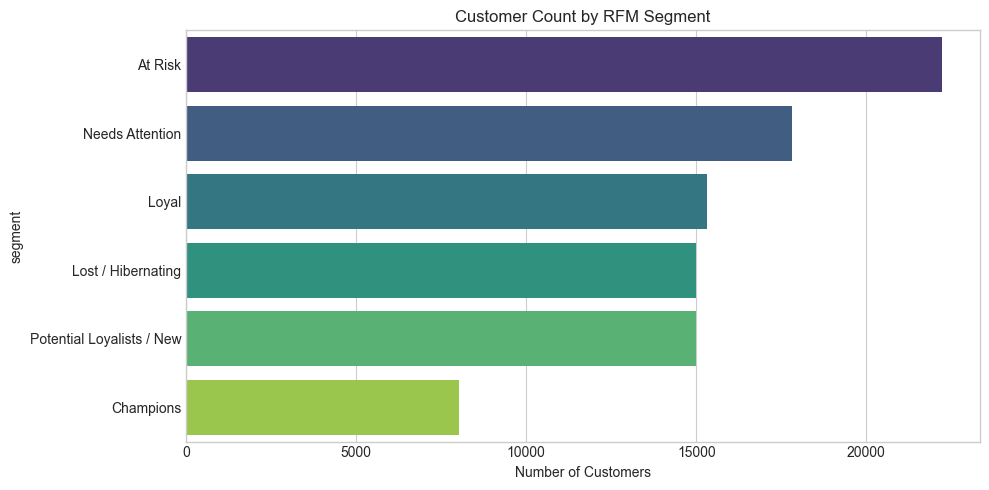

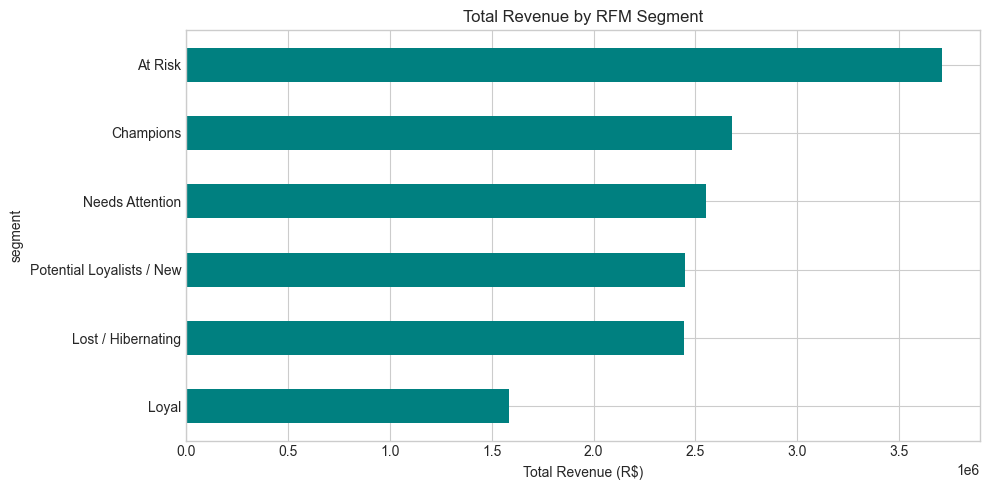

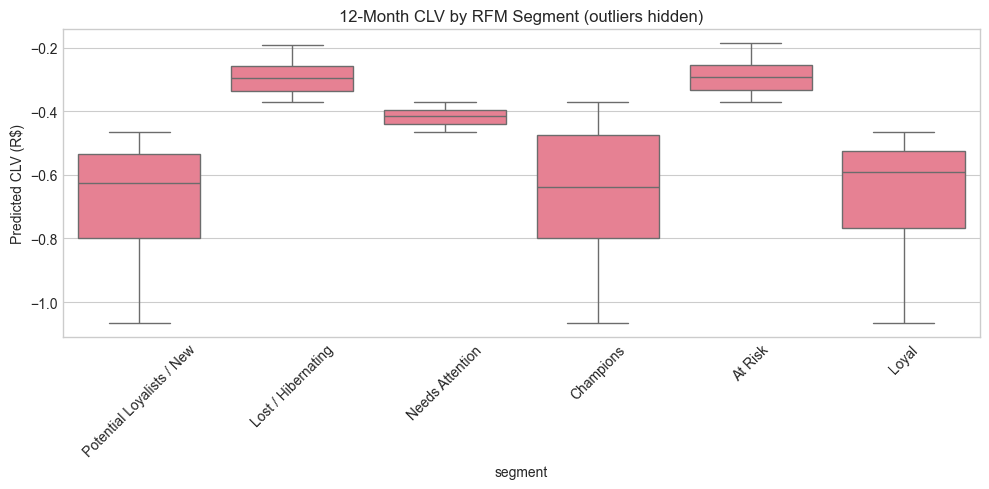

In [10]:
# RFM Segment distribution
plt.figure(figsize=(10, 5))
order = rfm['segment'].value_counts().index
sns.countplot(data=rfm, y='segment', order=order, palette='viridis')
plt.title('Customer Count by RFM Segment')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'rfm_segment_counts.png', dpi=150)
plt.show()

# Revenue by RFM Segment
rev = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 5))
rev.plot(kind='barh', color='teal')
plt.title('Total Revenue by RFM Segment')
plt.xlabel('Total Revenue (R$)')
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'rfm_revenue.png', dpi=150)
plt.show()

# CLV distribution by segment
if 'clv' in dir() or 'clv_12m' in clv.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=clv, x='segment', y='clv_12m', showfliers=False)
    plt.xticks(rotation=45)
    plt.title('12-Month CLV by RFM Segment (outliers hidden)')
    plt.ylabel('Predicted CLV (R$)')
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / 'clv_by_segment.png', dpi=150)
    plt.show()